In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [7]:
df = pd.read_csv("Airbnb_EDA_Final.csv")
print("Dataset Loaded Successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Loaded Successfully
Rows: 99330
Columns: 20


In [8]:
df.head()


,Unnamed: 0,index,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews
0,0,0,Clean & quiet apt home by the park,80014485718,UNCONFIRMED,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,0,strict,Private room,2020.0,966,193.0,10.0,9.0
1,1,1,Skylit Midtown Castle,52335172823,VERIFIED,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,0,moderate,Entire home/apt,2007.0,142,28.0,30.0,45.0
2,2,4,Entire Apt: Spacious Studio/Loft by central park,92037596077,VERIFIED,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,0,moderate,Entire home/apt,2009.0,204,41.0,10.0,9.0
3,3,5,Large Cozy 1 BR Apartment In Midtown East,45498551794,VERIFIED,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,US,1,flexible,Entire home/apt,2013.0,577,115.0,3.0,74.0
4,4,7,BlissArtsSpace!,90821839709,UNCONFIRMED,Emma,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,US,0,moderate,Private room,2009.0,1060,212.0,45.0,49.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99330 entries, 0 to 99329
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              99330 non-null  int64  
 1   index                   99330 non-null  int64  
 2   NAME                    99330 non-null  object 
 3   host id                 99330 non-null  int64  
 4   host_identity_verified  99330 non-null  object 
 5   host name               99330 non-null  object 
 6   neighbourhood group     99330 non-null  object 
 7   neighbourhood           99330 non-null  object 
 8   lat                     99330 non-null  float64
 9   long                    99330 non-null  float64
 10  country                 99330 non-null  object 
 11  country code            99330 non-null  object 
 12  instant_bookable        99330 non-null  int64  
 13  cancellation_policy     99330 non-null  object 
 14  room type               99330 non-null

In [10]:
print(df.columns.tolist())

['Unnamed: 0', 'index', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews']


In [11]:
df.dtypes

,0
Unnamed: 0,int64
index,int64
NAME,object
host id,int64
host_identity_verified,object
host name,object
neighbourhood group,object
neighbourhood,object
lat,float64
long,float64


In [12]:
numeric_columns = df.select_dtypes(include='number').columns.tolist()
print("Numerical Columns:")
for col in numeric_columns:
  print(col)

Numerical Columns:
Unnamed: 0
index
host id
lat
long
instant_bookable
Construction year
price
service fee
minimum nights
number of reviews


In [13]:
features = ['price','service fee','minimum nights','number of reviews']
X = df[features].copy()

print("Selected features:")
print(X.columns.tolist())

print("\nShape of clustering dataset:")
print(X.shape)

X.head()


Selected features:
['price', 'service fee', 'minimum nights', 'number of reviews']

Shape of clustering dataset:
(99330, 4)


,price,service fee,minimum nights,number of reviews
0,966,193.0,10.0,9.0
1,142,28.0,30.0,45.0
2,204,41.0,10.0,9.0
3,577,115.0,3.0,74.0
4,1060,212.0,45.0,49.0


In [14]:
print(X.isnull().sum())

price                0
service fee          0
minimum nights       0
number of reviews    0
dtype: int64


In [15]:
print("Negative Minimum Nights:",(X['minimum nights']<0).sum())

Negative Minimum Nights: 0


In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original Shape:", X.shape)
print("Scaled Shape:", X_scaled.shape)


Original Shape: (99330, 4)
Scaled Shape: (99330, 4)


In [17]:
X_scaled[:5]

array([[ 1.02651259,  1.02343761,  0.06332686, -0.37211054],
       [-1.45740703, -1.46337258,  0.72714666,  0.35726633],
       [-1.27051016, -1.26744208,  0.06332686, -0.37211054],
       [-0.14611451, -0.15214539, -0.16901007,  0.94481991],
       [ 1.30987235,  1.30979757,  1.2250115 ,  0.4383082 ]])

In [18]:
inertia = []

K_range = range(2,11)

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)

  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

  print("Inertia values:")
  for k, value in zip(K_range, inertia):
    print(f"K={k}: {value:.2f}")
#

Inertia values:
K=2: 248679.01
Inertia values:
K=2: 248679.01
K=3: 194518.52
Inertia values:
K=2: 248679.01
K=3: 194518.52
K=4: 144080.54
Inertia values:
K=2: 248679.01
K=3: 194518.52
K=4: 144080.54
K=5: 117985.93
Inertia values:
K=2: 248679.01
K=3: 194518.52
K=4: 144080.54
K=5: 117985.93
K=6: 96714.88
Inertia values:
K=2: 248679.01
K=3: 194518.52
K=4: 144080.54
K=5: 117985.93
K=6: 96714.88
K=7: 85458.52
Inertia values:
K=2: 248679.01
K=3: 194518.52
K=4: 144080.54
K=5: 117985.93
K=6: 96714.88
K=7: 85458.52
K=8: 74919.79
Inertia values:
K=2: 248679.01
K=3: 194518.52
K=4: 144080.54
K=5: 117985.93
K=6: 96714.88
K=7: 85458.52
K=8: 74919.79
K=9: 66047.46
Inertia values:
K=2: 248679.01
K=3: 194518.52
K=4: 144080.54
K=5: 117985.93
K=6: 96714.88
K=7: 85458.52
K=8: 74919.79
K=9: 66047.46
K=10: 60622.68


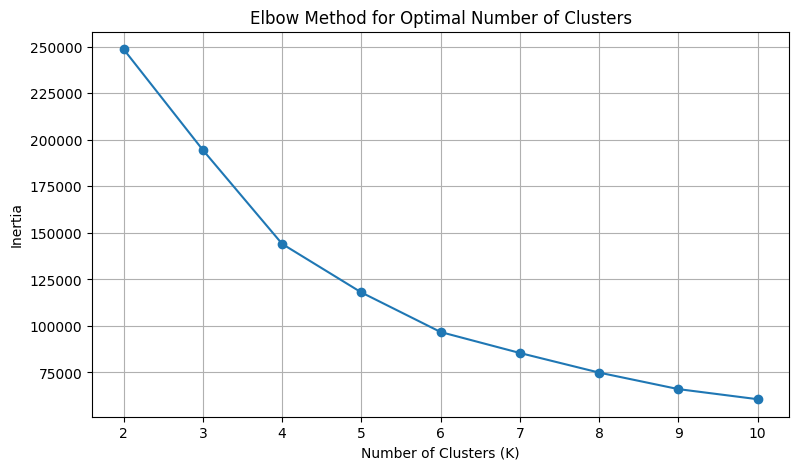

In [19]:
plt.figure(figsize=(9,5))

plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)

plt.show()
#

In [21]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Use a sample for faster silhouette calculation

X_sample = X_scaled[:1000]

silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    labels = kmeans.fit_predict(X_sample)

    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)

    print(f"K={k}: Silhouette Score = {score:.4f}")



K=2: Silhouette Score = 0.9724
K=3: Silhouette Score = 0.4395
K=4: Silhouette Score = 0.4664
K=5: Silhouette Score = 0.4222
K=6: Silhouette Score = 0.4004
K=7: Silhouette Score = 0.4139
K=8: Silhouette Score = 0.3468
K=9: Silhouette Score = 0.3607
K=10: Silhouette Score = 0.3614


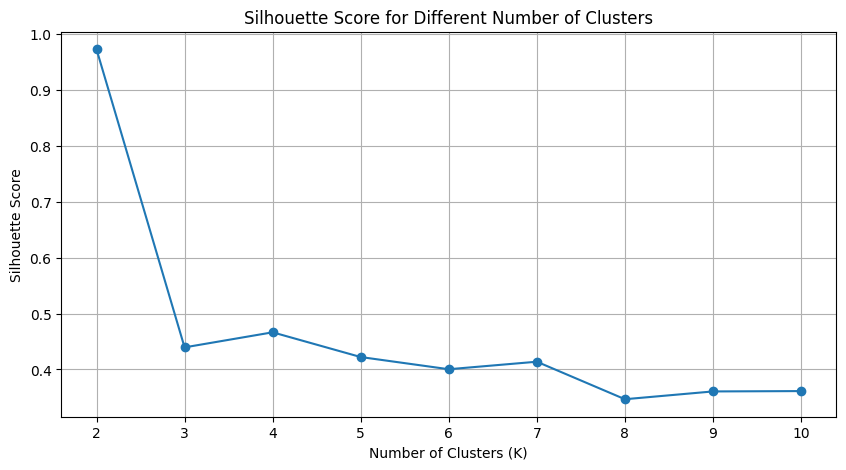

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(range(2,11), silhouette_scores, marker='o')

plt.title('Silhouette Score for Different Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.show()


In [36]:
eda_df = df.copy()

eda_df['Cluster'] = cluster_labels

print("K-Means clustering completed successflly")
print("Number of Clusters:", eda_df['Cluster'].nunique())

K-Means clustering completed successflly
Number of Clusters: 2


In [37]:
cluster_counts = eda_df['Cluster'].value_counts().sort_index()

print("Number of listings in each Cluster:")
print(cluster_counts)

Number of listings in each Cluster:
Cluster
0    49405
1    49925
Name: count, dtype: int64


In [38]:
cluster_summary = eda_df.groupby('Cluster')[numeric_columns].mean()

print("Cluster Charactristics:")
print(cluster_summary)

Cluster Charactristics:
           Unnamed: 0         index  ...  minimum nights  number of reviews
Cluster                              ...                                   
0        49811.688028  51324.584070  ...        8.072240          27.436960
1        49535.304737  51041.502033  ...        8.111647          27.296445

[2 rows x 11 columns]


In [39]:
cluster_features = ['price','service fee','minimum nights','number of reviews']
cluster_summary = eda_df.groupby('Cluster')[cluster_features].mean()

print("Cluster Characteristics:")
print(cluster_summary)

Cluster Characteristics:
              price  service fee  minimum nights  number of reviews
Cluster                                                            
0        913.926688   182.788584        8.072240          27.436960
1        340.019990    68.002043        8.111647          27.296445


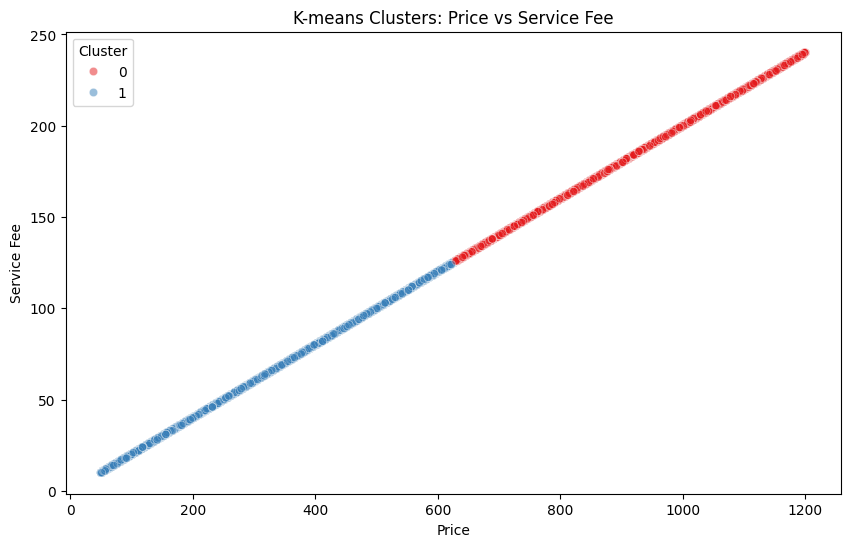

In [40]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = eda_df,x='price',y='service fee',hue='Cluster',palette='Set1',alpha=0.5)

plt.title('K-means Clusters: Price vs Service Fee')
plt.xlabel('Price')
plt.ylabel('Service Fee')
plt.legend(title='Cluster')
plt.show()



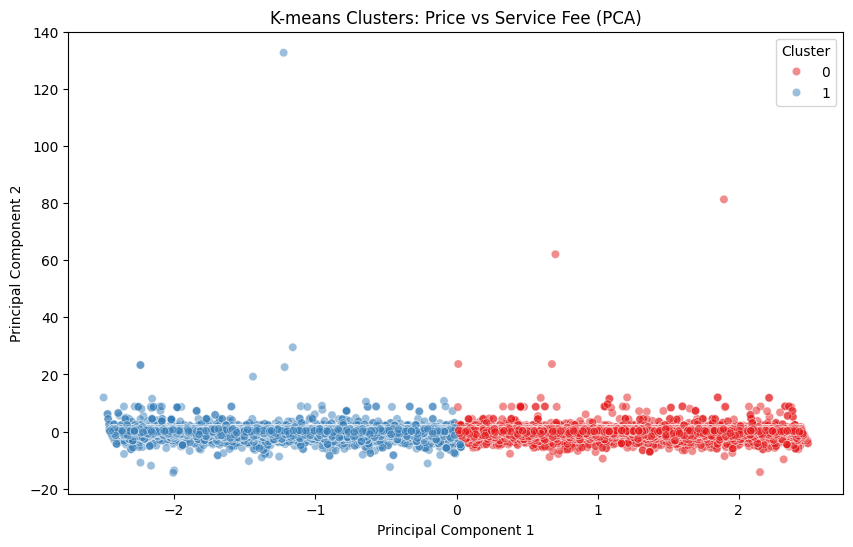

In [41]:
from sklearn.decomposition import PCA

# Reduce 4 clustering features to 2 dimentions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA Dataframe
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = eda_df['Cluster'].values

# Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set1', alpha=0.5)

plt.title('K-means Clusters: Price vs Service Fee (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [42]:
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, davies_bouldin_score)

# Evaluation Metrics
silhouette = silhouette_score(X_scaled, cluster_labels)
calinski = calinski_harabasz_score(X_scaled, cluster_labels)
davies = davies_bouldin_score(X_scaled, cluster_labels)

print("K-means Clustering Metrics:")
print("---------------------------")
print("Silhouette Score:",round(silhouette,4))
print("Calinski-Harabasz Index:",round(calinski,2))
print("Davies-Bouldin Index:",round(davies,4))

K-means Clustering Metrics:
---------------------------
Silhouette Score: 0.4576
Calinski-Harabasz Index: 59370.98
Davies-Bouldin Index: 0.8747


In [44]:
print("X_scaled shaoe:",X_scaled.shape)
print("Cluster labels length:",len(cluster_labels))
print("Unique clusters:",np.unique(cluster_labels))

print("Final Silhouette Score:",silhouette_score(X_scaled, cluster_labels))


X_scaled shaoe: (99330, 4)
Cluster labels length: 99330
Unique clusters: [0 1]
Final Silhouette Score: 0.457596892778991


In [45]:
print("Number of rows in eda_df:", len(eda_df))
print("Number of rows in X_scaled:", len(X_scaled))

Number of rows in eda_df: 99330
Number of rows in X_scaled: 99330


In [46]:
# Save the final clustered dataset
eda_df.to_csv("Clustered_Data.csv", index=False)

print("Clustered dataset saved successfully")
print("File shape:",eda_df.shape)

Clustered dataset saved successfully
File shape: (99330, 21)


In [47]:
print(eda_df[['Cluster','price','service fee','minimum nights','number of reviews']].head())

   Cluster  price  service fee  minimum nights  number of reviews
0        0    966        193.0            10.0                9.0
1        1    142         28.0            30.0               45.0
2        1    204         41.0            10.0                9.0
3        1    577        115.0             3.0               74.0
4        0   1060        212.0            45.0               49.0


In [48]:
# Compare the average value of important features between clusters

cluster_comparison = eda_df.groupby('Cluster')[['price','service fee','minimum nights','number of reviews']].mean()

print("Average Characteristics of each cluster:")
print(cluster_comparison.round(2))

Average Characteristics of each cluster:
          price  service fee  minimum nights  number of reviews
Cluster                                                        
0        913.93       182.79            8.07              27.44
1        340.02        68.00            8.11              27.30


In [49]:
# count the number of listings in each cluster

cluster_counts = eda_df['Cluster'].value_counts().sort_index()

print("Number of listings in each cluster:")
print(cluster_counts)

Number of listings in each cluster:
Cluster
0    49405
1    49925
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

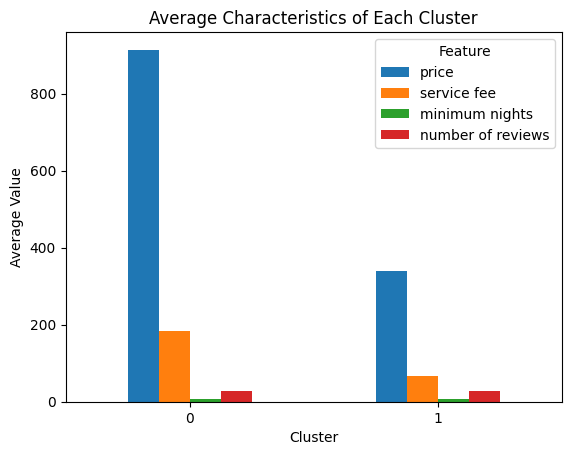

In [50]:
plt.figure(figsize=(8,5))

cluster_comparison.plot(kind='bar')

plt.title('Average Characteristics of Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Feature')

plt.show()